Saving HR_comma_sep.csv to HR_comma_sep.csv
🔹 Shape: (14999, 10)
🔹 Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
✅ Shapes for CNN: (11999, 18, 1) (3000, 18, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,945 (42.75 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 192 (768.00 B)


✅ CNN evaluation on test set
Loss: 0.0879 | Accuracy: 0.9753

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.96      0.93      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000



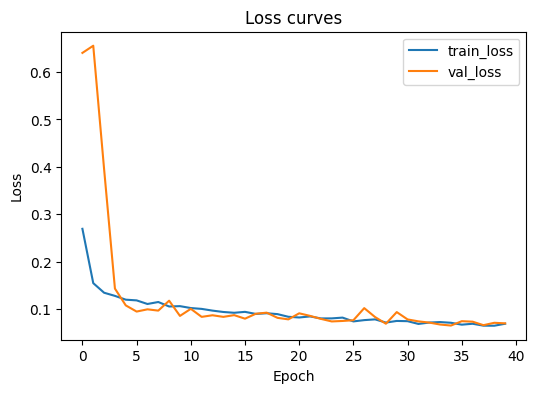

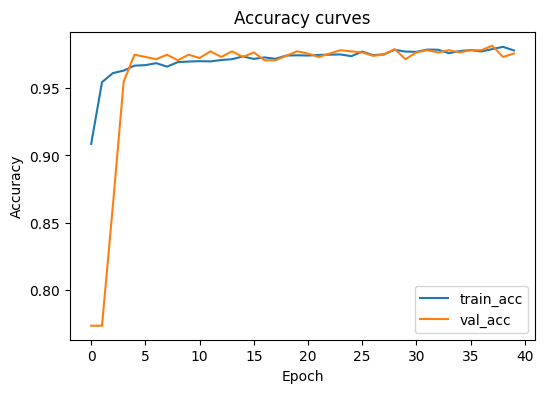

In [1]:
# 🌟 Exercise 1 : Simple CNN with Keras (on tabular data as 1D sequence)
# -----------------------------------------------------------------------------
# Steps:
# 1) Import libraries (incl. Keras / TensorFlow)
# 2) Upload and load dataset (HR_comma_sep.csv)
# 3) Clean/encode: one-hot for categoricals, scale numeric features
# 4) Train/test split
# 5) Build a 1D CNN with .Sequential()
# 6) Compile & Train (with EarlyStopping)
# 7) Evaluate test loss & accuracy
# -----------------------------------------------------------------------------

# 1) Imports
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 2) Load dataset
df = pd.read_csv("HR_comma_sep.csv")

print("🔹 Shape:", df.shape)
print("🔹 Columns:", df.columns.tolist())
print(df.head(3))

# Typical columns in this dataset:
# ['satisfaction_level','last_evaluation','number_project','average_montly_hours',
#  'time_spend_company','Work_accident','left','promotion_last_5years','sales','salary']

# 3) Clean/encode
# Rename 'sales' -> 'department' if present (clarity)
if 'sales' in df.columns:
    df = df.rename(columns={'sales':'department'})

target_col = 'left'
assert target_col in df.columns, "Target column 'left' not found."

# One-hot encode categoricals if present
cat_cols = [c for c in ['department','salary'] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Split features/target
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Reshape for 1D CNN: (samples, timesteps, channels)
# Here: timesteps = n_features, channels = 1
n_features = X_train.shape[1]
X_train_cnn = X_train.reshape((-1, n_features, 1))
X_test_cnn  = X_test.reshape((-1, n_features, 1))

print("✅ Shapes for CNN:", X_train_cnn.shape, X_test_cnn.shape)

# 6) Build CNN model
model = keras.Sequential([
    layers.Input(shape=(n_features, 1)),
    # 1D convolution over the feature dimension
    layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")  # binary classification
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# 7) Train with EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=6, restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0  # set to 1 if you want logs
)

# 8) Evaluate
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
y_prob = model.predict(X_test_cnn, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n✅ CNN evaluation on test set")
print(f"Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: quick plot of training curves (loss & accuracy)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
